### Smoothing a noisy signal

Use convolution to smooth a signal. Given two vectors $a$ and $b$ ($b$ is called "kernel"), with $\operatorname{dim}(a) = N$ and $\operatorname{dim}(b) = M$, the $i$-th coefficient of the convolution vector $a * b$ is defined as:

$$
    (a * b)_{i} = \sum_{m} \, a_{m} \, b_{i - m}
$$

For smoothing, we need the condition $\sum_{m} \, b_{m} = 1$ for the kernel

In [1]:
# Package
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [2]:
# Noisy signal generation
t = np.linspace(0, 4 * np.pi, 256)
y_noisy = np.sin(t) + np.random.normal(loc = 0, scale = 0.3, size = len(t))
y_noisy

array([ 0.17097317, -0.1400807 ,  0.08515683,  0.22063835,  0.60053144,
        0.23391275, -0.1123666 ,  0.53084856,  0.40844419,  0.42111996,
        0.94360516,  1.16928518,  0.43061303,  0.76822079,  1.02521311,
        0.56990422,  1.03363773,  0.7012643 ,  1.14224936,  0.63984142,
        0.52318215,  0.81155131,  0.94400498,  1.24252829,  1.12046671,
        0.77448491,  0.86195266,  1.23083693,  1.32832767,  0.6911605 ,
        1.27026764,  0.96833715,  0.19565545,  0.80799445,  1.0025175 ,
        1.19884438,  0.62701454,  0.95453504,  1.20163807,  0.91722899,
        0.77377501,  1.27948535,  1.15433365,  0.70048432,  1.1914771 ,
        0.56902336,  0.54209221,  0.98911209,  1.16848635,  0.80524253,
        1.1613061 ,  0.21874232, -0.03851569,  0.51426879,  0.6099296 ,
        0.216538  ,  0.54319103,  0.21351497,  0.35747086,  0.15757448,
       -0.0266615 ,  0.53567708, -0.20430285, -0.05547778,  0.29811385,
       -0.36979387,  0.24067558, -0.87322525, -0.170275  , -0.31

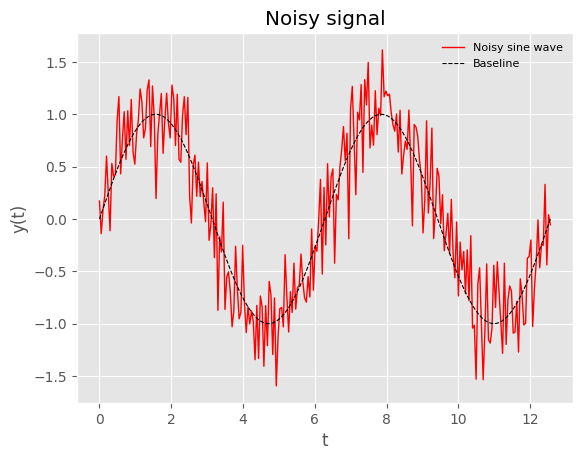

In [3]:
# Visualization
plt.title('Noisy signal')
plt.plot(t, y_noisy, color = 'red', linewidth = 1, label = 'Noisy sine wave')
plt.plot(t, np.sin(t), color = 'black', linestyle = '--', linewidth = 0.8, label = 'Baseline')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend(loc = 'best', frameon = False, fontsize = 8)
plt.show()

### Rectangular smoothing

The easiest method: take the average of data in window of fixed length

In [4]:
def rect_smoothing(window_size): # Rectangular smoothing function
    global y_noisy

    kernel = np.ones(window_size) / window_size
    y_smooth = np.convolve(y_noisy, kernel, mode ='same')

    return y_smooth

In [5]:
y_smooth_rect3 = rect_smoothing(3)
y_smooth_rect5 = rect_smoothing(5)
y_smooth_rect7 = rect_smoothing(7)
y_smooth_rect15 = rect_smoothing(15)

### Triangular Smoothing

Similar to the previous technique but with different weights for kernel

In [6]:
def triangular_smoothing(window_size): # Triangular smoothing function
    global y_noisy

    peak = (window_size + 1) // 2
    kernel = np.convolve(np.ones(peak), np.ones(peak))
    kernel /= np.sum(kernel)

    y_smooth = np.convolve(y_noisy, kernel, mode = 'same')
    return y_smooth

In [7]:
y_smooth_tri3 = triangular_smoothing(3)
y_smooth_tri5 = triangular_smoothing(5)
y_smooth_tri7 = triangular_smoothing(7)
y_smooth_tri15 = triangular_smoothing(15)

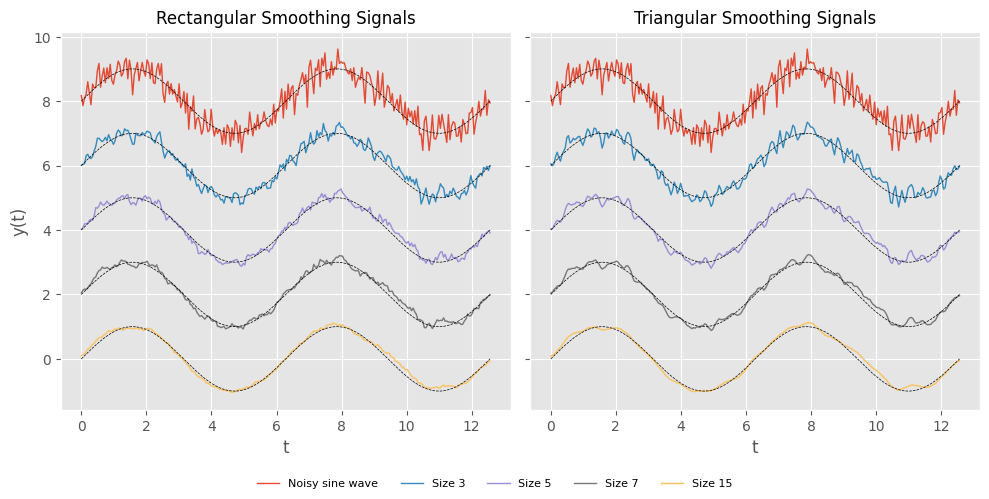

In [8]:
# Plotting results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5), sharey = True)

# Left plot: rectangular smoothing signals
ax1.set_title('Rectangular Smoothing Signals', fontsize = 12)
ax1.plot(t, y_noisy + 8, linewidth = 1, label = 'Noisy sine wave')
ax1.plot(t, y_smooth_rect3 + 6, linewidth = 1, label = 'Size 3')
ax1.plot(t, y_smooth_rect5 + 4, linewidth = 1, label = 'Size 5')
ax1.plot(t, y_smooth_rect7 + 2, linewidth = 1, label = 'Size 7')
ax1.plot(t, y_smooth_rect15, linewidth = 1, label = 'Size 15')

for j in range(0, 9, 2):
    ax1.plot(t, np.sin(t) + j, color = 'black', linestyle = '--', linewidth = 0.5)
ax1.set_xlabel('t')
ax1.set_ylabel('y(t)')

# Right plot: triangular smoothing signals
ax2.set_title('Triangular Smoothing Signals', fontsize = 12)
ax2.plot(t, y_noisy + 8, linewidth = 1)
ax2.plot(t, y_smooth_tri3 + 6, linewidth = 1)
ax2.plot(t, y_smooth_tri5 + 4, linewidth = 1)
ax2.plot(t, y_smooth_tri7 + 2, linewidth = 1)
ax2.plot(t, y_smooth_tri15, linewidth = 1)

for j in range(0, 9, 2):
    ax2.plot(t, np.sin(t) + j, color = 'black', linestyle = '--', linewidth = 0.5)
ax2.set_xlabel('t')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc = 'lower center', ncol = 5, frameon = False, fontsize = 8)

plt.tight_layout()
fig.subplots_adjust(bottom = 0.17)
plt.show()

### Savitzky-Golay Smoothing Filter

The Savitzky-Golay technique smoothes noisy data by fitting successive sub-sets of adjacent data points with a low-degree polynomial using the method of linear least squares.

In [9]:
from scipy.signal import savgol_filter # From SciPy

In [10]:
sav = savgol_filter( # Savitzky-Golay smoothing with window length 33 and polynomial order 3
    x = y_noisy,
    window_length = 33,
    polyorder = 3
)

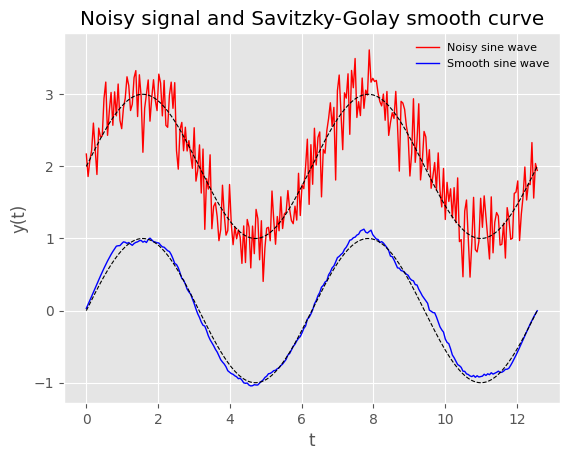

In [11]:
# Visualization
plt.title('Noisy signal and Savitzky-Golay smooth curve')
plt.plot(t, y_noisy + 2, color = 'red', linewidth = 1, label = 'Noisy sine wave')
plt.plot(t, sav, color = 'blue', linewidth = 1, label = 'Smooth sine wave')
for j in range(0, 3, 2):
    plt.plot(t, np.sin(t) + j, color = 'black', linestyle = '--', linewidth = 0.8)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend(loc = 'best', frameon = False, fontsize = 8)
plt.show()